In [1]:
%cd /home/smalani/PartialObservations
from config import config

%cd /home/smalani/PartialObservations/BandFModel
import datagen
import numpy as np
import torch
import matplotlib.pyplot as plt

/home/smalani/PartialObservations
/home/smalani/PartialObservations/BandFModel


In [2]:
%cd /home/smalani/PartialObservations/BandFModel
f = np.load("../minmax/minmax.npz")

xmax = f['arr_0']
xmin = f['arr_1']
print(xmax)
print(xmin)

norm_func = lambda input: (input - xmin) / (xmax - xmin + 1e-10)

inv_norm_func = lambda input: input * (xmax - xmin + 1e-10) + xmin

# assert False

/home/smalani/PartialObservations/BandFModel
[7.76480999e+01 6.13450077e-02 3.52889567e-01 2.08507400e+02
 2.11354658e+03 8.21362308e-01]
[1.45181035e+01 1.12344629e-04 2.81247634e-01 3.24970859e+01
 3.97881635e+02 6.58996734e-01]


In [3]:
%cd /home/smalani/PartialObservations/
data_train = datagen.generate_data(n_train=50, detail=True, duplicate_reverse=True)

/home/smalani/PartialObservations


  0%|          | 0/50 [00:00<?, ?it/s]

pakapaaakaaa detail
(50, 6)


In [4]:
x_data = data_train[0]

t_in = data_train[2]
x_in = data_train[3]
p_in = data_train[4]

print(x_in.shape)
print(x_data.shape)

(50, 1000, 6)
(50, 6)


In [5]:
# %cd /home/smalani/PartialObservations
# np.savez('minmax/initialcond',x_in)

f = np.load('minmax/limitcycle_detail.npz')
myvar0_detail = f['arr_0']

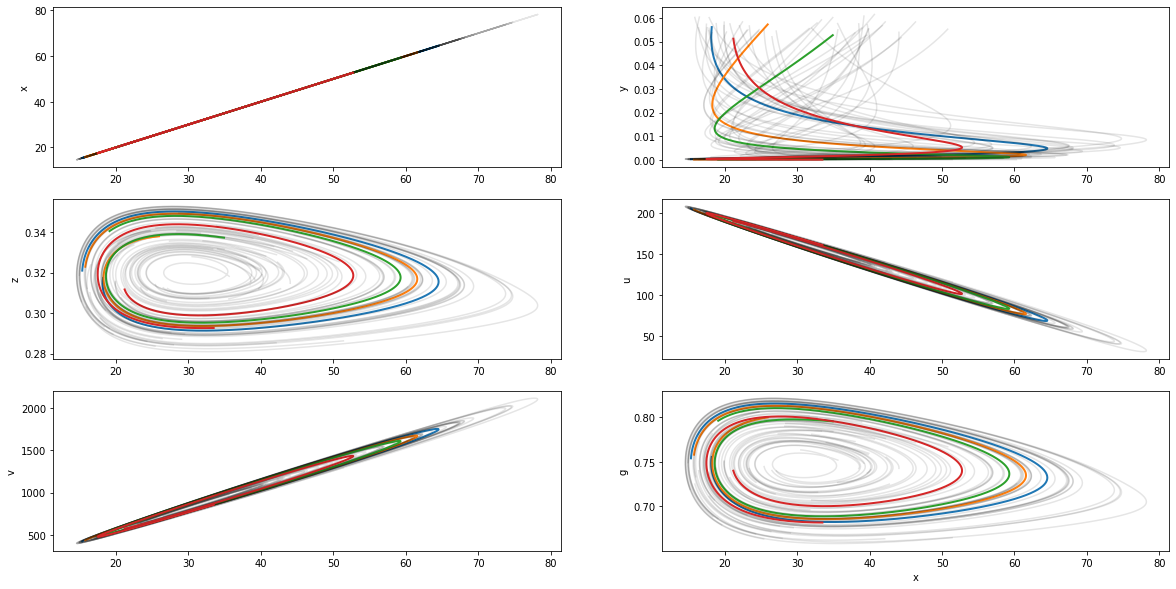

In [12]:
plt.figure(figsize=(20,10))

num_plot = 3

labels = ['x', 'y', 'z', 'u', 'v', 'g']
for i in range(6):
    plt.subplot(int(str(32) + str(i+1)))
    for j in range(x_in.shape[0]):
        if j % int((x_in.shape[0])/num_plot) == 0:
            plt.plot(x_in[j,:,0], x_in[j,:,i], linewidth=2)
        else:
            plt.plot(x_in[j,:,0], x_in[j,:,i], alpha=0.1, c='k')
        plt.ylabel(labels[i])
plt.xlabel('x')
plt.show()
plt.savefig('Figures/TrainingData_LimitCycle', bbox_extra_artists=(lgd,), bbox_inches='tight')

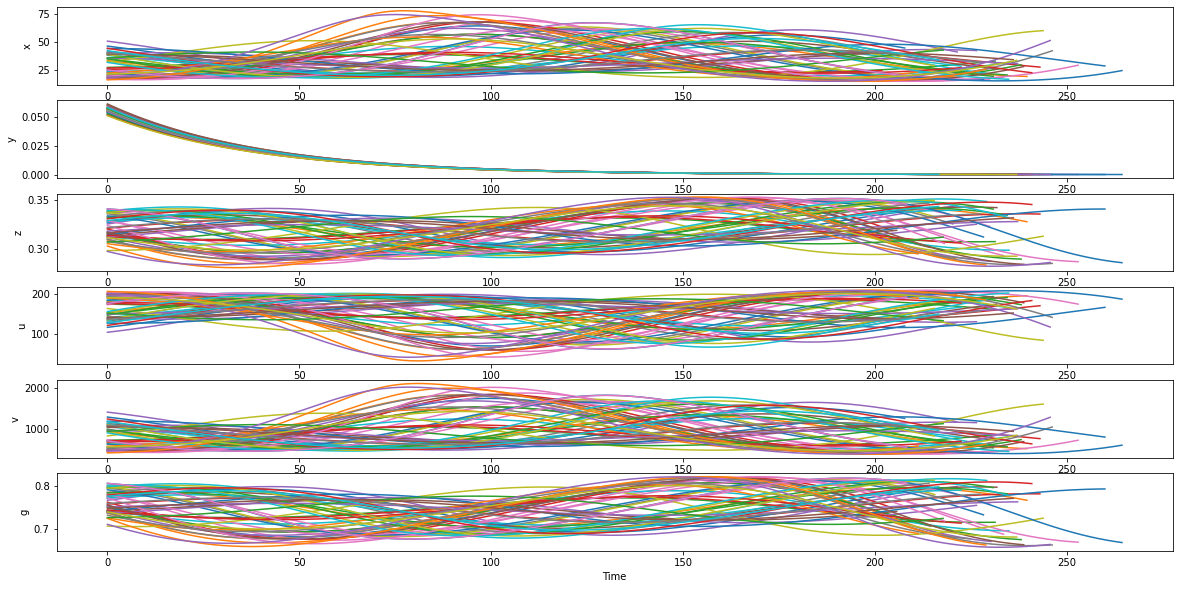

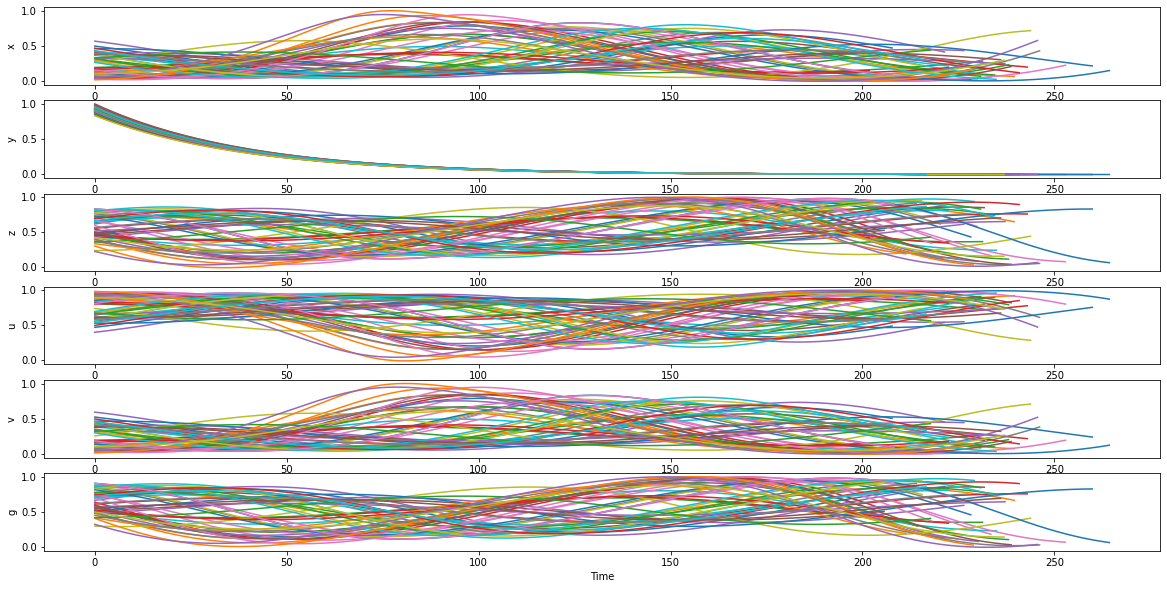

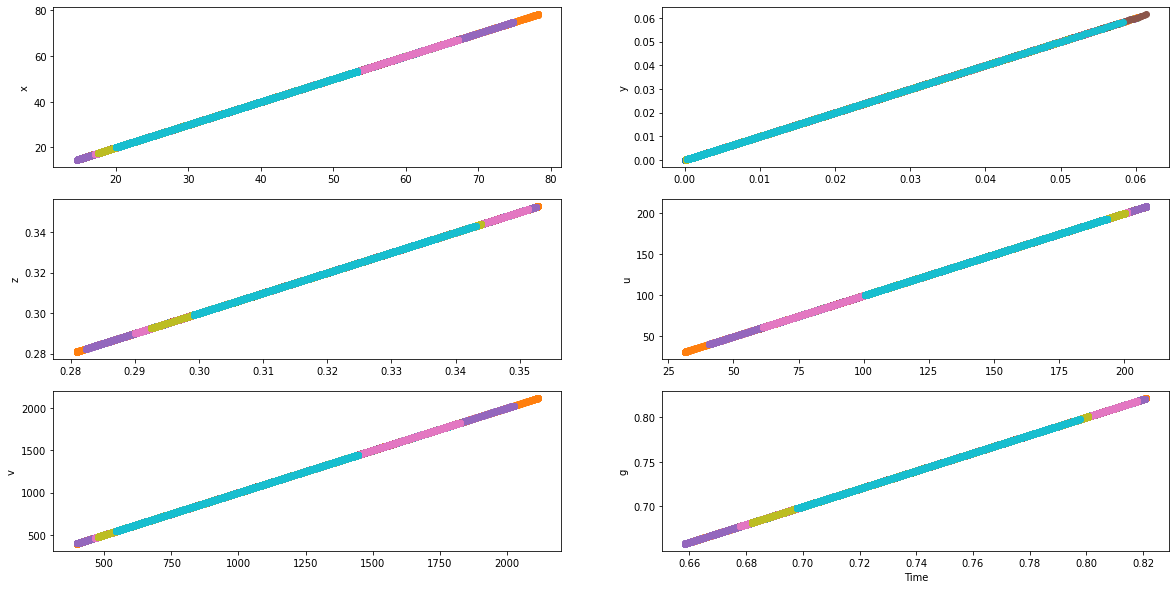

In [7]:
plt.figure(figsize=(20,10))

labels = ['x', 'y', 'z', 'u', 'v', 'g']
for i in range(6):
    plt.subplot(int(str(61) + str(i+1)))
    for j in range(x_in.shape[0]):
        plt.plot(t_in[j,:], x_in[j,:,i])
        plt.ylabel(labels[i])
plt.xlabel('Time')
plt.show()

plt.figure(figsize=(20,10))

labels = ['x', 'y', 'z', 'u', 'v', 'g']
for i in range(6):
    plt.subplot(int(str(61) + str(i+1)))
    for j in range(x_in.shape[0]):
        plt.plot(t_in[j,:], norm_func(x_in)[j,:,i])
        plt.ylabel(labels[i])
plt.xlabel('Time')
plt.show()

plt.figure(figsize=(20,10))

labels = ['x', 'y', 'z', 'u', 'v', 'g']
for i in range(6):
    plt.subplot(int(str(32) + str(i+1)))
    for j in range(x_in.shape[0]):
        plt.scatter(inv_norm_func(norm_func(x_in))[j,:,i], x_in[j,:,i])
        plt.ylabel(labels[i])
plt.xlabel('Time')
plt.show()

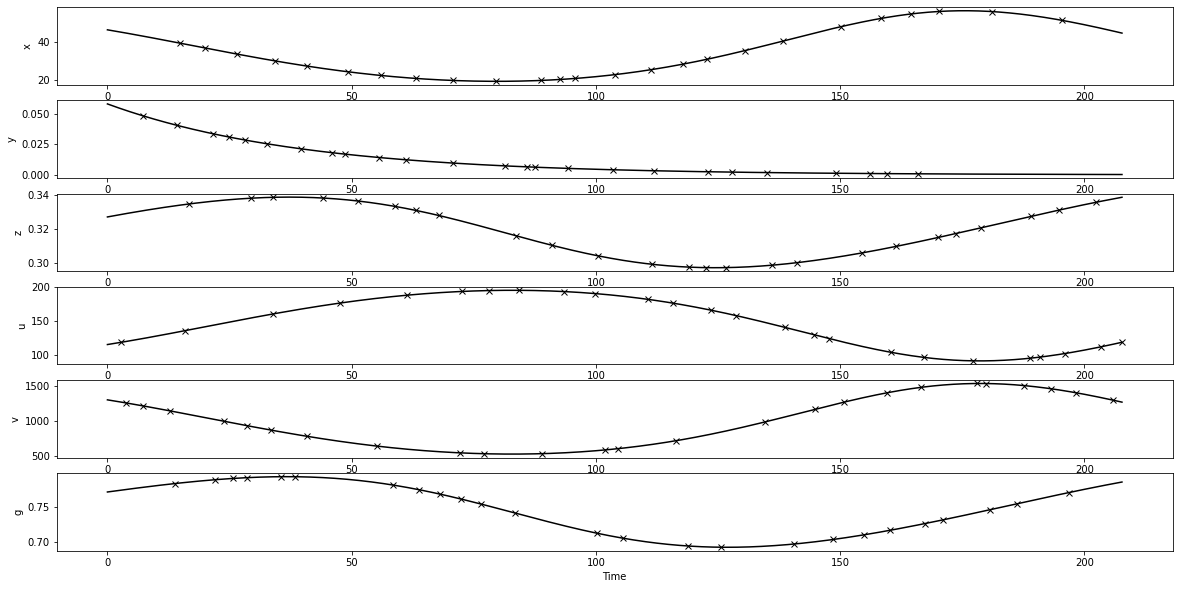

IndexError: index 60 is out of bounds for axis 0 with size 50

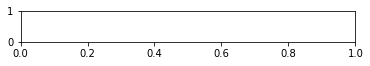

In [8]:
plt.figure(figsize=(20,10))

j = 10

labels = ['x', 'y', 'z', 'u', 'v', 'g']
for i in range(6):
    plt.subplot(int(str(61) + str(i+1)))
    plt.plot(t_in[j,:], x_in[j,:,i], 'k-')
    plt.plot(x_data[j,i][1], x_data[j,i][0], 'kx')
    plt.ylabel(labels[i])
plt.xlabel('Time')
plt.show()

# j = j + 50

labels = ['x', 'y', 'z', 'u', 'v', 'g']
for i in range(6):
    plt.subplot(int(str(61) + str(i+1)))
    plt.plot(t_in[j+50,:], x_in[j+50,:,i], 'k-')
    plt.plot(x_data[j,i][1], x_data[j,i][0], 'kx')
    plt.ylabel(labels[i])
plt.xlabel('Time')
plt.show()

In [ ]:
print(x_data.shape)
print(x_data[0,0].shape)